# Размещение объектов с помощью кластеризации

Сгруппируем географические координаты методом K-Means, выберем число кластеров по inertia и получим центры возможного размещения объектов.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

,latitude,longitude,source_cluster
0,55.673879,37.557432,0
1,55.611053,37.368607,0
2,55.567805,37.462786,0
3,55.569550,37.226374,0
4,55.795292,37.675949,0


Размер: (1260, 3)


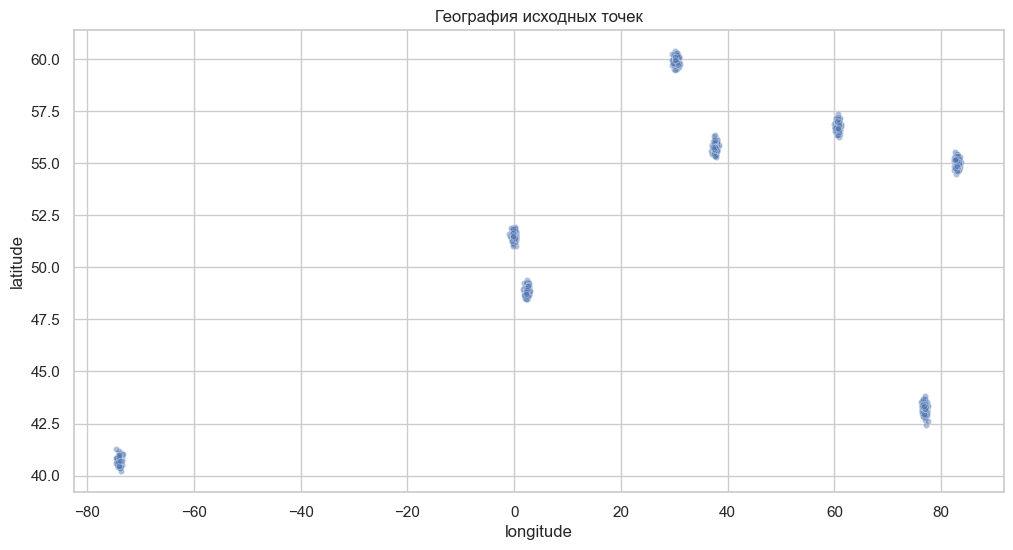

In [2]:
checkins = pd.read_csv("checkins.csv")
display(checkins.head())
print("Размер:", checkins.shape)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=checkins, x="longitude", y="latitude", alpha=0.45, s=20)
plt.title("География исходных точек")
plt.show()

## Метод локтя

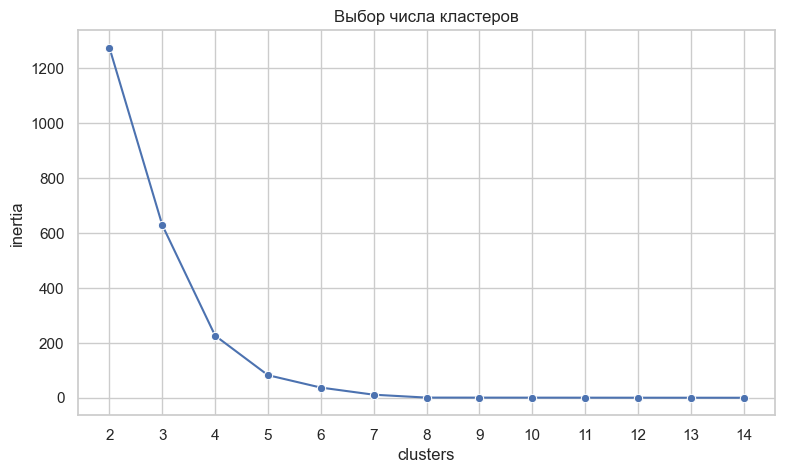

In [3]:
coordinates = checkins[["latitude", "longitude"]]
scaled_coordinates = StandardScaler().fit_transform(coordinates)
inertia_rows = []
for clusters in range(2, 15):
    model = KMeans(n_clusters=clusters, n_init=20, random_state=42)
    model.fit(scaled_coordinates)
    inertia_rows.append({"clusters": clusters, "inertia": model.inertia_})

inertia = pd.DataFrame(inertia_rows)
plt.figure(figsize=(9, 5))
sns.lineplot(data=inertia, x="clusters", y="inertia", marker="o")
plt.title("Выбор числа кластеров")
plt.xticks(inertia["clusters"])
plt.show()

## Итоговые центры

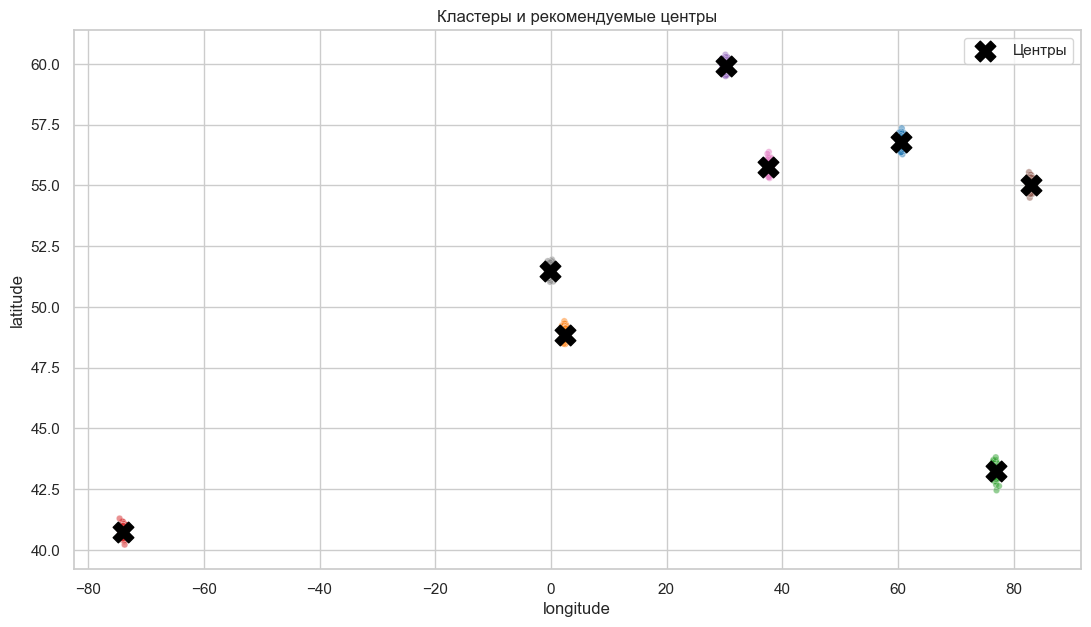

,latitude,longitude
0,40.745287,-73.975528
1,51.475831,-0.096761
2,48.859096,2.406120
3,59.923878,30.332964
4,55.762865,37.620927
5,56.802114,60.599911
6,43.231792,76.899340
7,55.028311,82.944311


In [4]:
model = KMeans(n_clusters=8, n_init=30, random_state=42)
checkins["cluster"] = model.fit_predict(scaled_coordinates)
centers_scaled = model.cluster_centers_
scaler = StandardScaler().fit(coordinates)
model = KMeans(n_clusters=8, n_init=30, random_state=42).fit(scaler.transform(coordinates))
checkins["cluster"] = model.labels_
centers_frame = pd.DataFrame(
    scaler.inverse_transform(model.cluster_centers_),
    columns=["latitude", "longitude"],
)

plt.figure(figsize=(13, 7))
sns.scatterplot(data=checkins, x="longitude", y="latitude", hue="cluster", palette="tab10", alpha=0.5, s=22, legend=False)
plt.scatter(centers_frame["longitude"], centers_frame["latitude"], marker="X", s=220, color="black", label="Центры")
plt.title("Кластеры и рекомендуемые центры")
plt.legend()
plt.show()

centers_frame.sort_values("longitude").reset_index(drop=True)

## Вывод

K-Means минимизирует расстояние до центров кластеров. Для географических задач необходимо учитывать масштаб координат и при реальном внедрении использовать корректную геодезическую метрику.

## Расширенная проверка кластеризации

In [5]:
import numpy as np
from sklearn.metrics import adjusted_rand_score, silhouette_score

### Качество исходных данных

In [6]:
pd.DataFrame({
    "rows": [len(checkins)],
    "missing": [int(checkins[["latitude", "longitude"]].isna().sum().sum())],
    "duplicates": [int(checkins[["latitude", "longitude"]].duplicated().sum())],
    "latitude_min": [checkins["latitude"].min()],
    "latitude_max": [checkins["latitude"].max()],
    "longitude_min": [checkins["longitude"].min()],
    "longitude_max": [checkins["longitude"].max()],
})

,rows,missing,duplicates,latitude_min,latitude_max,longitude_min,longitude_max
0,1260,0,0,40.212639,60.378755,-74.625689,83.746015


### Silhouette score

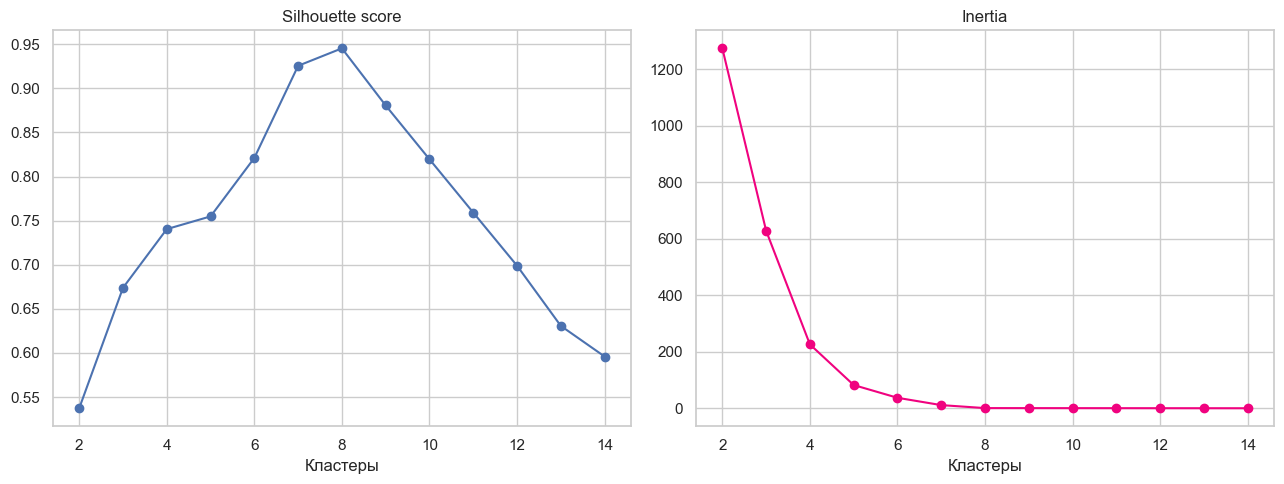

In [7]:
silhouette_rows = []
for clusters in range(2, 15):
    candidate = KMeans(n_clusters=clusters, n_init=20, random_state=42)
    labels = candidate.fit_predict(scaled_coordinates)
    silhouette_rows.append({
        "clusters": clusters,
        "silhouette": silhouette_score(scaled_coordinates, labels),
        "inertia": candidate.inertia_,
    })

silhouette_results = pd.DataFrame(silhouette_rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(silhouette_results["clusters"], silhouette_results["silhouette"], marker="o")
axes[0].set_title("Silhouette score")
axes[0].set_xlabel("Кластеры")
axes[1].plot(silhouette_results["clusters"], silhouette_results["inertia"], marker="o", color="#f0027f")
axes[1].set_title("Inertia")
axes[1].set_xlabel("Кластеры")
plt.tight_layout()
plt.show()

### Размер и компактность кластеров

In [8]:
center_array = centers_frame[["latitude", "longitude"]].to_numpy()
point_array = checkins[["latitude", "longitude"]].to_numpy()
assigned_centers = center_array[checkins["cluster"].to_numpy()]
checkins["distance_to_center"] = np.sqrt(((point_array - assigned_centers) ** 2).sum(axis=1))

cluster_summary = checkins.groupby("cluster").agg(
    points=("cluster", "size"),
    mean_distance=("distance_to_center", "mean"),
    p95_distance=("distance_to_center", lambda values: values.quantile(0.95)),
    latitude=("latitude", "mean"),
    longitude=("longitude", "mean"),
)
cluster_summary

,points,mean_distance,p95_distance,latitude,longitude
cluster,,,,,
0,180,0.265085,0.516693,56.802114,60.599911
1,120,0.278374,0.500800,48.859096,2.406120
2,180,0.264935,0.563584,43.231792,76.899340
3,120,0.272706,0.545100,40.745287,-73.975528
4,180,0.277036,0.553122,59.923878,30.332964
5,180,0.268718,0.515031,55.028311,82.944311
6,180,0.255672,0.531001,55.762865,37.620927
7,120,0.279076,0.548376,51.475831,-0.096761


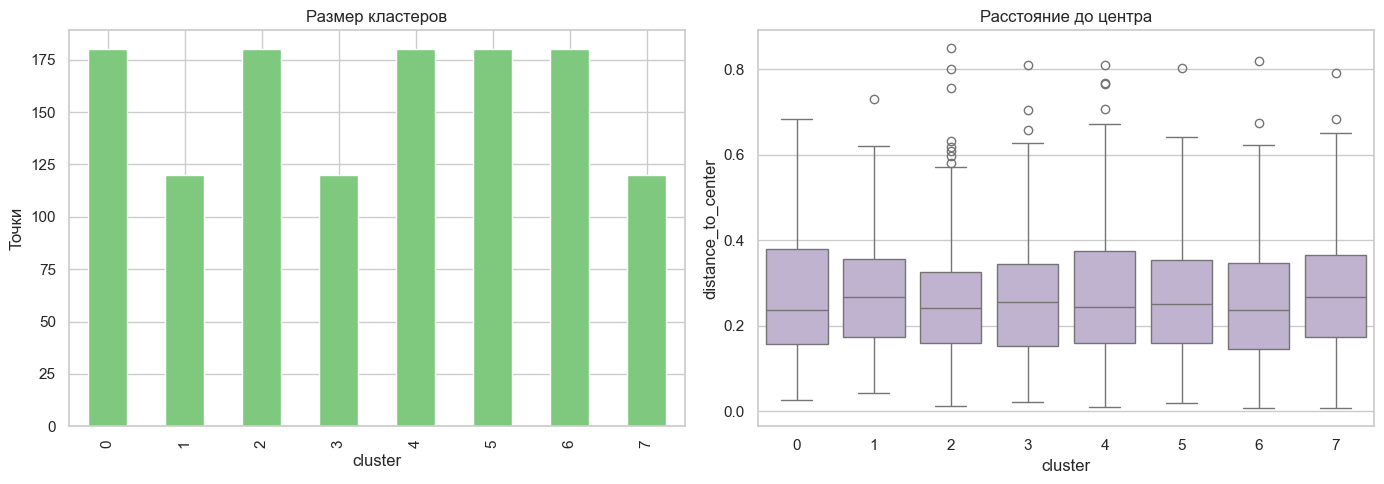

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cluster_summary["points"].plot.bar(ax=axes[0], color="#7fc97f")
axes[0].set_title("Размер кластеров")
axes[0].set_ylabel("Точки")
sns.boxplot(data=checkins, x="cluster", y="distance_to_center", ax=axes[1], color="#beaed4")
axes[1].set_title("Расстояние до центра")
plt.tight_layout()
plt.show()

### Аномально удалённые точки

,latitude,longitude,source_cluster,cluster,distance_to_center
898,42.625332,77.492511,4,2,0.848320
129,55.853453,38.435057,0,6,0.819153
336,59.718408,29.549183,1,4,0.810266
993,41.290269,-74.574294,5,3,0.809646
641,55.033697,83.746015,3,5,0.801722
832,42.448859,77.058206,4,2,0.798888
1020,51.616612,-0.874256,6,7,0.790138
301,59.955559,29.566842,1,4,0.766777
326,60.232901,29.632013,1,4,0.766047
834,43.512390,76.196711,4,2,0.756586


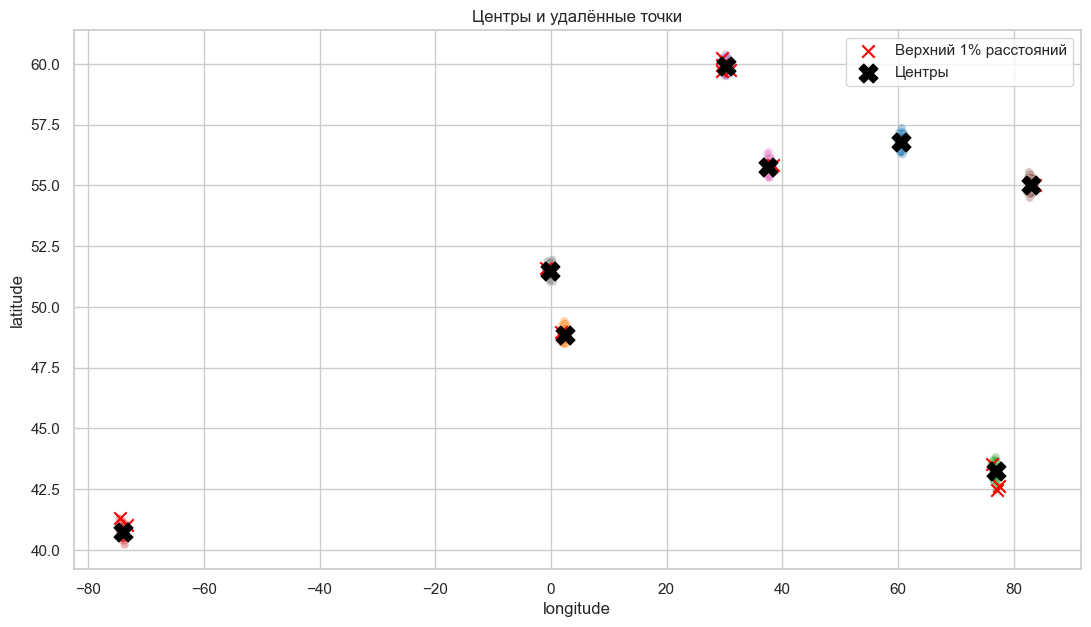

In [10]:
outlier_threshold = checkins["distance_to_center"].quantile(0.99)
outliers = checkins[checkins["distance_to_center"] >= outlier_threshold].sort_values("distance_to_center", ascending=False)
display(outliers.head(15))

plt.figure(figsize=(13, 7))
sns.scatterplot(data=checkins, x="longitude", y="latitude", hue="cluster", palette="tab10", alpha=0.35, legend=False)
plt.scatter(outliers["longitude"], outliers["latitude"], color="red", marker="x", s=80, label="Верхний 1% расстояний")
plt.scatter(centers_frame["longitude"], centers_frame["latitude"], color="black", marker="X", s=180, label="Центры")
plt.title("Центры и удалённые точки")
plt.legend()
plt.show()

### Сравнение с известной синтетической разметкой

In [11]:
ari = adjusted_rand_score(checkins["source_cluster"], checkins["cluster"])
pd.Series({
    "adjusted_rand_index": ari,
    "selected_clusters": checkins["cluster"].nunique(),
    "source_clusters": checkins["source_cluster"].nunique(),
}).to_frame("value")

,value
adjusted_rand_index,1.0
selected_clusters,8.0
source_clusters,8.0


### Итог расширенного анализа

Inertia всегда уменьшается при росте числа кластеров, поэтому её нужно дополнять silhouette score. Размеры и расстояния до центров показывают компактность сегментов, а анализ удалённых точек помогает не размещать объект в центре шумового кластера.